In [16]:
import pandas as pd
import networkx as nx
import os

# 1. Percorsi e Caricamento
proc_path = os.path.join('..', 'data', 'processed')
nodes_cleaned = pd.read_csv(os.path.join(proc_path, 'nodes_cleaned.csv'))
edges_cleaned = pd.read_csv(os.path.join(proc_path, 'edges_cleaned.csv'))

# 2. Identificazione Seme Golden Power
seed_celex = '32019R0452'
# Usiamo direttamente seed_celex dato che ora id e celex coincidono
seed_id = seed_celex 

# 3. Estrazione dei vicini (Rete Golden Power)
# Filtriamo gli archi dove la sorgente o il target è il nostro seme
connections = edges_cleaned[(edges_cleaned['source'] == seed_id) | (edges_cleaned['target'] == seed_id)]
neighbor_ids = set(connections['source']) | set(connections['target'])

# Filtriamo i nodi che fanno parte di questa rete
network_data = nodes_cleaned[nodes_cleaned['celex'].isin(neighbor_ids)]

# 4. Creazione dell'oggetto G
G = nx.Graph()
for _, row in network_data.iterrows():
    # Usiamo 'celex' come ID del nodo e 'title' come attributo
    G.add_node(row['celex'], title=row['title'], celex=row['celex'])

for _, row in connections.iterrows():
    # Aggiungiamo l'arco solo se entrambi i nodi esistono nel nostro estratto
    if row['source'] in G.nodes and row['target'] in G.nodes:
        G.add_edge(row['source'], row['target'])

# 5. Calcolo delle posizioni (pos)
pos = nx.spring_layout(G, k=0.5, seed=42)

print(f"Grafo 'G' ricostruito con {G.number_of_nodes()} nodi e {G.number_of_edges()} archi.")

Grafo 'G' ricostruito con 39 nodi e 38 archi.


In [17]:
# Il CELEX del Regolamento Golden Power (UE 2019/452)
seed_celex = '32019R0452'

# 1. Verifica che il seme esista nel dataset normalizzato
seed_node = nodes_cleaned[nodes_cleaned['celex'] == seed_celex]

if seed_node.empty:
    print(f"Errore: CELEX {seed_celex} non trovato nei nodi puliti!")
else:
    # Dato che abbiamo normalizzato, l'ID è il CELEX stesso
    seed_id = seed_celex 
    
    # 2. Trova i vicini (chi cita il seme e chi è citato dal seme)
    # source = chi cita | target = chi è citato
    connections = edges_cleaned[(edges_cleaned['source'] == seed_id) | (edges_cleaned['target'] == seed_id)]
    
    # Otteniamo tutti i CELEX dei nodi connessi
    neighbor_ids = set(connections['source']) | set(connections['target'])
    
    # 3. Estrai i dettagli di queste leggi dal dataframe arricchito
    golden_power_network = nodes_cleaned[nodes_cleaned['celex'].isin(neighbor_ids)]
    
    print(f"Analisi Rete Golden Power:")
    print(f"- Leggi connesse trovate: {len(golden_power_network)}")
    print(f"- Numero di relazioni totali: {len(connections)}")

Analisi Rete Golden Power:
- Leggi connesse trovate: 39
- Numero di relazioni totali: 40


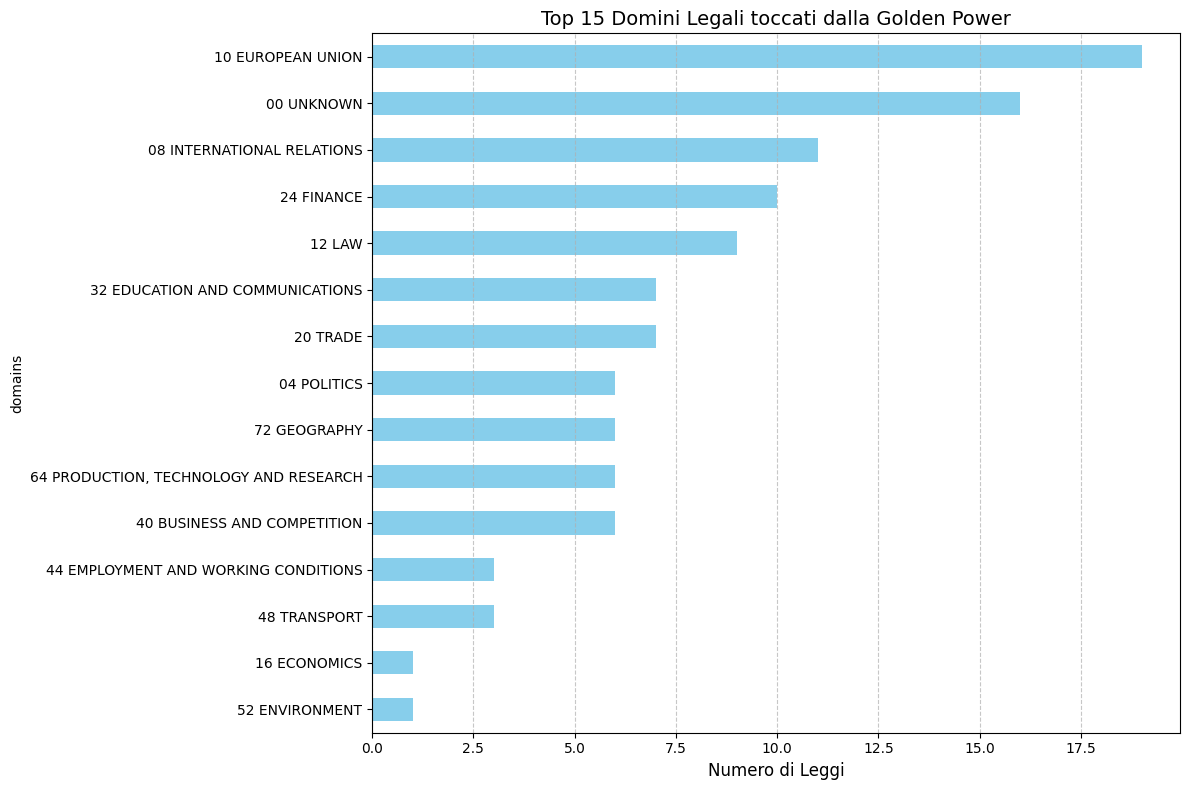

In [18]:
# 1. Rompiamo le stringhe in liste e "esplodiamole"
# Trasformiamo 'A;B;C' in tre righe distinte: A, B e C
domains_exploded = golden_power_network['domains'].dropna().str.split(';').explode()

# 2. Puliamo eventuali spazi bianchi ai bordi
domains_exploded = domains_exploded.str.strip()

# 3. Contiamo le occorrenze dei singoli domini
clean_domain_counts = domains_exploded.value_counts()

# 4. Creiamo un grafico molto più chiaro
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
clean_domain_counts.head(15).plot(kind='barh', color='skyblue') # Usiamo barre orizzontali per leggere meglio i nomi
plt.title("Top 15 Domini Legali toccati dalla Golden Power", fontsize=14)
plt.xlabel("Numero di Leggi", fontsize=12)
plt.gca().invert_yaxis() # Mette il più frequente in alto
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
import plotly.graph_objects as go

# 1. Prepariamo i colori per i domini
node_colors = []
for node in G.nodes():
    # 'node' qui è il CELEX. Cerchiamo i dati in golden_power_network
    row = golden_power_network[golden_power_network['celex'] == node].iloc[0]
    dom_string = str(row['domains'])
    
    if dom_string and dom_string != '00 UNKNOWN':
        # Prendiamo l'ID numerico del primo dominio
        dom_id = dom_string.split(' ')[0]
        try:
            node_colors.append(int(dom_id))
        except:
            node_colors.append(0)
    else:
        node_colors.append(0)

# 2. Traccia degli ARCHI
edge_x, edge_y = [], []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(x=edge_x, y=edge_y, line=dict(width=0.5, color='#888'), hoverinfo='none', mode='lines')

# 3. Traccia dei NODI
node_x, node_y, node_text = [], [], []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    
    # Recuperiamo i dati arricchiti
    row = golden_power_network[golden_power_network['celex'] == node].iloc[0]
    celex = row['celex']
    title = row['title']
    dom = row['domains']
    year = row['year']
    l_type = row['legal_type']
    
    # Tooltip pulito e informativo
    hover_label = (f"<b>CELEX:</b> {celex}<br>"
                   f"<b>Anno:</b> {year} | <b>Tipo:</b> {l_type}<br>"
                   f"<b>Dominio:</b> {dom}<br>"
                   f"<b>Titolo:</b> {title[:75]}...")
    node_text.append(hover_label)

node_trace = go.Scatter(
    x=node_x, y=node_y, mode='markers', hoverinfo='text', text=node_text,
    marker=dict(
        showscale=True,
        colorscale='Viridis', # Scala più professionale e leggibile della Rainbow
        size=14,
        line_width=2,
        color=node_colors,
        colorbar=dict(
            thickness=15,
            title=dict(text='ID Dominio EuroVoc', side='right'),
            xanchor='left'
        )
    )
)

# 4. Creazione FIGURA
fig_final = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title=dict(text='Network Golden Power: Frammentazione Tematica (Dati Normalizzati)', font=dict(size=16)),
                showlegend=False, hovermode='closest', margin=dict(b=20,l=5,r=5,t=40),
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
                )

fig_final.show()

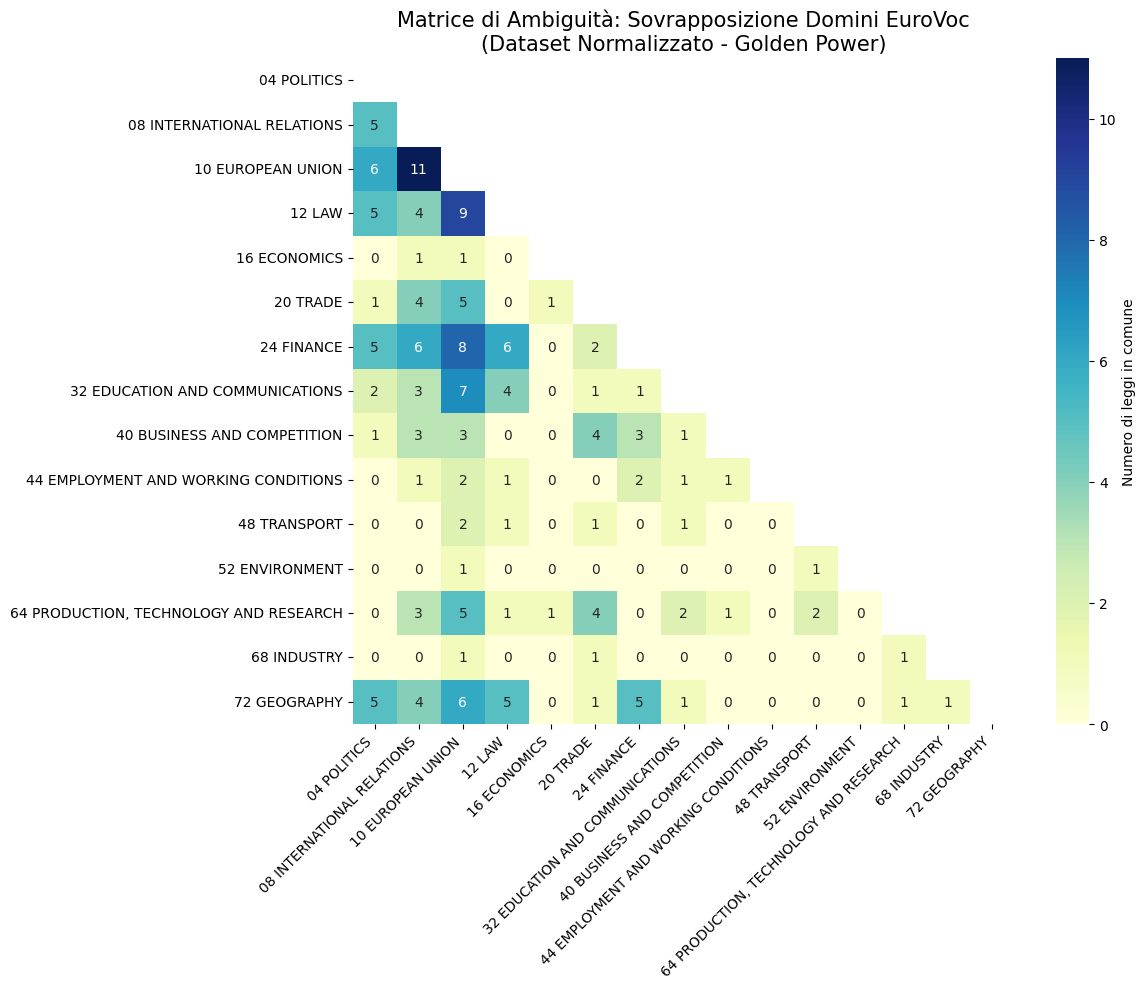

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
from collections import Counter

# 1. Preparazione dei dati dal dataframe arricchito
# Usiamo 'domains' dal tuo network filtrato e rimuoviamo i casi sconosciuti
dom_series = golden_power_network[golden_power_network['domains'] != '00 UNKNOWN']['domains'].dropna()

def get_domain_list(text):
    # La pulizia precedente potrebbe aver rimosso i ';' 
    # Adattiamo la separazione per gestire virgole o punti e virgola
    if ';' in text:
        return [p.strip() for p in text.split(';')]
    elif ',' in text:
        return [p.strip() for p in text.split(',')]
    else:
        return [text.strip()]

# 2. Calcolo delle Co-occorrenze
pair_counts = Counter()
all_domains = set()

for entry in dom_series:
    domains = get_domain_list(str(entry))
    all_domains.update(domains)
    # Creiamo coppie uniche di domini presenti nella stessa legge
    for pair in combinations(sorted(domains), 2):
        pair_counts[pair] += 1

# 3. Selezione dei Top Domain per la matrice
# Contiamo la frequenza totale per non affollare il grafico
flat_domains = [d for entry in dom_series for d in get_domain_list(str(entry))]
top_domains = pd.Series(flat_domains).value_counts().head(15).index.tolist()
unique_domains = sorted(top_domains)

matrix = pd.DataFrame(0, index=unique_domains, columns=unique_domains)

for (d1, d2), count in pair_counts.items():
    if d1 in unique_domains and d2 in unique_domains:
        matrix.loc[d1, d2] = count
        matrix.loc[d2, d1] = count

# 4. Visualizzazione
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(matrix, dtype=bool))

sns.heatmap(matrix, mask=mask, annot=True, fmt='d', cmap='YlGnBu', 
            cbar_kws={'label': 'Numero di leggi in comune'})

plt.title('Matrice di Ambiguità: Sovrapposizione Domini EuroVoc\n(Dataset Normalizzato - Golden Power)', fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Salvataggio nella cartella dei risultati
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/co_occurrence_matrix_final.png')
plt.show()